In [85]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import cv2 
import os
import torch.nn.functional as F
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer

# Dataset

## Preprocess csv_file

In [86]:
df = pd.read_csv("/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv", delimiter="|")
df.columns = ['image', 'caption_number', 'caption']
df['caption'] = df['caption'].str.lstrip()
df['caption_number'] = df['caption_number'].str.lstrip()
df.loc[19999, 'caption_number'] = "4"
df.loc[19999, 'caption'] = "A dog runs across the grass ."
ids = [id_ for id_ in range(len(df) // 5) for i in range(5)]
df['id'] = ids
df.to_csv("captions.csv", index=False)
df.head()

,image,caption_number,caption,id
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...,0
1,1000092795.jpg,1,"Two young , White males are outside near many ...",0
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,0
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .,0
4,1000092795.jpg,4,Two friends enjoy time spent together .,0


In [87]:
df.head(10)

,image,caption_number,caption,id
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...,0
1,1000092795.jpg,1,"Two young , White males are outside near many ...",0
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,0
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .,0
4,1000092795.jpg,4,Two friends enjoy time spent together .,0
5,10002456.jpg,0,Several men in hard hats are operating a giant...,1
6,10002456.jpg,1,Workers look down from up above on a piece of ...,1
7,10002456.jpg,2,Two men working on a machine wearing hard hats .,1
8,10002456.jpg,3,Four men on top of a tall structure .,1
9,10002456.jpg,4,Three men on a large rig .,1


## Hyperparameters

In [108]:
image_path = "/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images"
captions_path = "."
batch_size = 32
num_workers = 4
head_lr = 1e-3
image_encoder_lr = 1e-4
text_encoder_lr = 1e-5
weight_decay = 1e-3
patience = 1
factor = 0.8
epochs = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "google/vit-base-patch16-224-in21k"
image_embedding = 768
text_encoder_model = "distilbert-base-uncased"
text_embedding = 768
text_tokenizer = "distilbert-base-uncased"
max_length = 200
size = 224 # Size of img

num_projection_layers = 1
projection_dim = 256 
dropout = 0.1

## Dataset

In [89]:
from torch.utils.data import Dataset,DataLoader,random_split
import albumentations as A
'''
Example output:
{
    "input_ids": tensor([...]),
    "attention_mask": tensor([...]),
    "image": tensor([...]),
    "caption": "A man is walking",
    "id": tensor(12)
}
'''
class CLIPDataset(Dataset):
    def __init__(self, image_filenames, captions, ids, tokenizer, transforms):
        """
        image_filenames and caption must have the same length; so, if there are
        multiple captions for each image, the image_filenames must have repetitive
        file names 
        """

        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.ids = ids
        self.encoded_captions = tokenizer(
            list(captions), padding=True, truncation=True, max_length=max_length
        )
        self.transforms = transforms

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx])
            for key, values in self.encoded_captions.items()
        }# Doan nay lay input_ids va attention_mask thoi.

        image = cv2.imread(f"{image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        item['image'] = torch.tensor(image).permute(2, 0, 1).float()
        item['caption'] = self.captions[idx]
        item['id'] = torch.tensor(self.ids[idx], dtype=torch.long)

        return item


    def __len__(self):
        return len(self.captions)



transforms = A.Compose([
                A.Resize(size, size, always_apply=True),
                A.Normalize(max_pixel_value=255.0, always_apply=True)])
tokenizer = DistilBertTokenizer.from_pretrained(text_tokenizer)

/tmp/ipykernel_58/985562993.py:51: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(size, size, always_apply=True),
/tmp/ipykernel_58/985562993.py:52: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True)])


In [90]:
dataset = CLIPDataset(df['image'].values,
                      df['caption'].values,
                      df['id'].values,
                     tokenizer,
                    transforms)
train_length = int(0.8 * len(dataset))
test_length = len(dataset) - train_length
train_dataset,test_dataset = random_split(dataset,lengths= [train_length,test_length])

In [91]:
train_dataloader = DataLoader(train_dataset,
                             batch_size = batch_size,
                              shuffle = True)
test_dataloader = DataLoader(test_dataset,
                            batch_size = batch_size,
                            shuffle = False)


In [92]:
mau = next(iter(train_dataloader))
mau['input_ids'].shape

torch.Size([32, 88])

data nay doan text duoc tokenizer -> 88 token

# Image Encoder

In [93]:
from transformers import ViTModel
class ImageEncoder(nn.Module):
    def __init__(self,model_name = model_name):
        super().__init__()
        self.model = ViTModel.from_pretrained(model_name)
        for parameter in self.model.parameters():
            parameter.requires_grad = True
    def forward(self, pixel_values):
        outputs = self.model(pixel_values=pixel_values)
        image_embedding = outputs.last_hidden_state[:, 0, :]
        return image_embedding

In [94]:
img = torch.rand(10,3,224,224)
Img_encoder = ImageEncoder(model_name)
Img_encoder(img).shape

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

torch.Size([10, 768])

In [95]:
class TextEncoder(nn.Module):
    def __init__(self,model_name = text_encoder_model,trainable = True):
        super().__init__()
        self.model = DistilBertModel.from_pretrained(model_name)
        for parameter in self.model.parameters():
            parameter.requires_grad = trainable
    def forward(self,input_ids,attention_mask):
        output = self.model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state # Learn how to use pre_trained model.
        return last_hidden_state[:,0,:]
        
        

Bert Model nen ta lay CLS token thoi thay vi lay full output

In [96]:
text_encoder = TextEncoder(text_encoder_model,True)
text = torch.randint(10,(10,100))
att_mask = torch.randint(1,(10,100))
text_encoder(text,att_mask).shape

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([10, 768])

In [100]:
class Projection_head(nn.Module):
    def __init__(self,emb_dim,proj_dim = projection_dim,dropout = 0.2):
        super( ).__init__()
        self.proj = nn.Linear(emb_dim,proj_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(proj_dim,proj_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(proj_dim)
    def forward(self,X):
        X = self.proj(X)
        next_X = self.gelu(X)
        next_X = self.fc(next_X)
        next_X = self.dropout(next_X)
        next_X += X
        next_X = self.layer_norm(next_X)
        return next_X

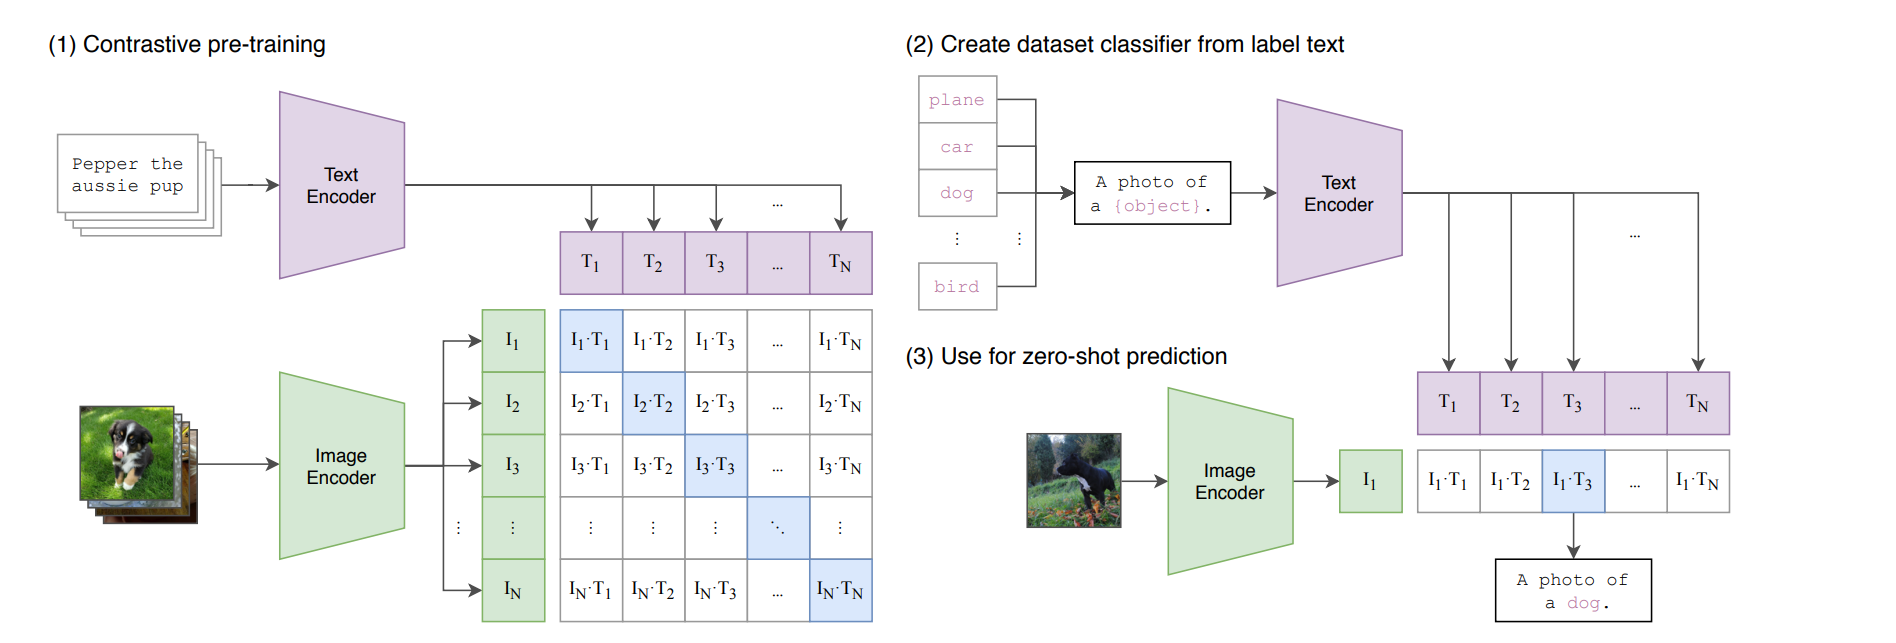

# CLIP

This implementation mitigate the risk of one image appears twice times in one batch

In [113]:
class CLIP(nn.Module):
    def __init__(self,img_emb = image_embedding,
                 text_emb = text_embedding,
                 proj_emb = projection_dim,
                 num_proj_layers = num_projection_layers,
                dropout = dropout):
        super().__init__()
        self.temperature = nn.Parameter(torch.exp(torch.tensor(0)))
        self.text_encoder = TextEncoder()
        self.img_encoder = ImageEncoder()
        self.text_proj = Projection_head(emb_dim = text_emb,proj_dim = proj_emb)
        self.img_proj = Projection_head(emb_dim = img_emb,proj_dim = proj_emb)
    def forward(self,X):
        img_features = self.img_encoder(X['image'])
        text_features = self.text_encoder(X['input_ids'],X['attention_mask'])
        ids = X['id'].float()
        proj_I = self.img_proj(img_features)
        proj_T = self.text_proj(text_features)
        logits = proj_I @ proj_T.T / self.temperature
        mask = ids[:,None] == ids[None,:]
        num_positive = mask.sum(dim = 1).clamp_min(1.0) # Num positive example in each img
        loss_i2t = - (mask * logits).sum(dim = 1) / num_positive # the minus help maximum positive example
        # We use T or dim = 0 for calculate loss text to image
        num_positive_t2i = mask.sum(dim = 0).clamp_min(1.0)
        loss_t2i = -(mask * logits).sum(dim = 0) / num_positive_t2i
        return (loss_t2i.mean() + loss_i2t.mean()) / 2

In [114]:
test_CLIP = CLIP()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

WORK PROPERLY :>

In [115]:
test_CLIP(mau)

tensor(0.5142, grad_fn=<DivBackward0>)